# Plot2Eq: Обучение модели

### Шаг 1: Настройка окружения и импорты

In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from tqdm.auto import tqdm
import numpy as np
import os
import sys

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.train import train_loop, TrainConfig  # noqa: E402
from src.model import Plot2EqModel  # noqa: E402
from src.tokenizer import Tokenizer  # noqa: E402
from src.dataset import SymbolicDataset  # noqa: E402
from src.datamodule import build_dataloaders  # noqa: E402

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cpu
CUDA available: False


### Шаг 2: Инспекция архитектуры

Давайте создадим экземпляр модели и посмотрим, сколько в ней обучаемых параметров. Это полезно для оценки требуемых ресурсов и сравнения с другими архитектурами.

In [2]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cfg = TrainConfig()
tokenizer = Tokenizer()

model = Plot2EqModel(
    vocab_size=len(tokenizer.tokens),
    pad_idx=tokenizer.token_map["<pad>"],
    d_model=cfg.d_model,
    nhead=cfg.nhead,
    num_enc_layers=cfg.num_enc_layers,
    num_dec_layers=cfg.num_dec_layers,
    dropout=cfg.dropout,
)

num_params = count_parameters(model)
print(f"Архитектура модели:\n{model}\n")
print(f"Общее количество обучаемых параметров: {num_params:,}")

Архитектура модели:
Plot2EqModel(
  (cnn_encoder): ConvNeXt1DEncoder(
    (stem): Sequential(
      (0): Conv1d(2, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (1): GroupNorm(1, 64, eps=1e-05, affine=True)
    )
    (stage1): Sequential(
      (0): ConvNeXt1DBlock(
        (dwconv): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), groups=64)
        (net): Sequential(
          (0): RMSNorm((64,), eps=None, elementwise_affine=True)
          (1): Linear(in_features=64, out_features=256, bias=True)
          (2): GELU(approximate='none')
          (3): Linear(in_features=256, out_features=64, bias=True)
        )
      )
      (1): ConvNeXt1DBlock(
        (dwconv): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), groups=64)
        (net): Sequential(
          (0): RMSNorm((64,), eps=None, elementwise_affine=True)
          (1): Linear(in_features=64, out_features=256, bias=True)
          (2): GELU(approximate='none')
          (3): Linear(in_features=2

### Шаг 3: Визуализация данных
Убедимся, что наш `SymbolicDataset` и аугментации работают как надо. Посмотрим на несколько примеров из датасета до и после `HandDrawnAugmentation`.

Загружаем 57 файлов в память


100%|██████████| 57/57 [00:05<00:00, 10.14it/s]


Примеры из датасета без аугментаций:


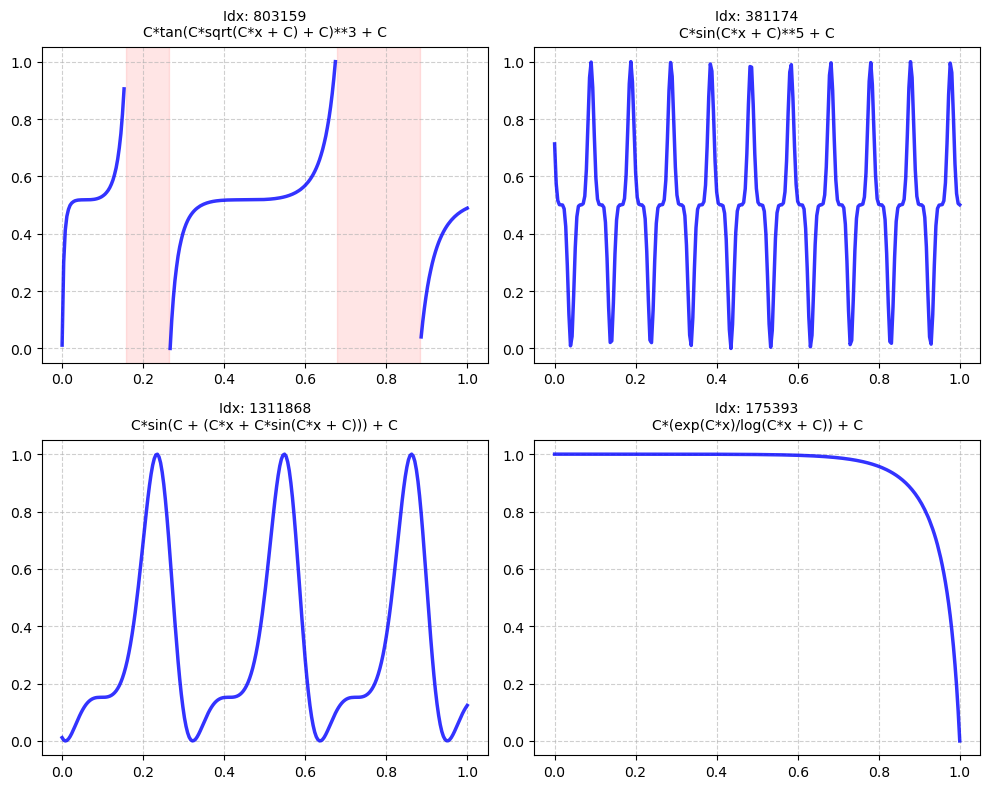

Те же примеры, но с аугментациями:


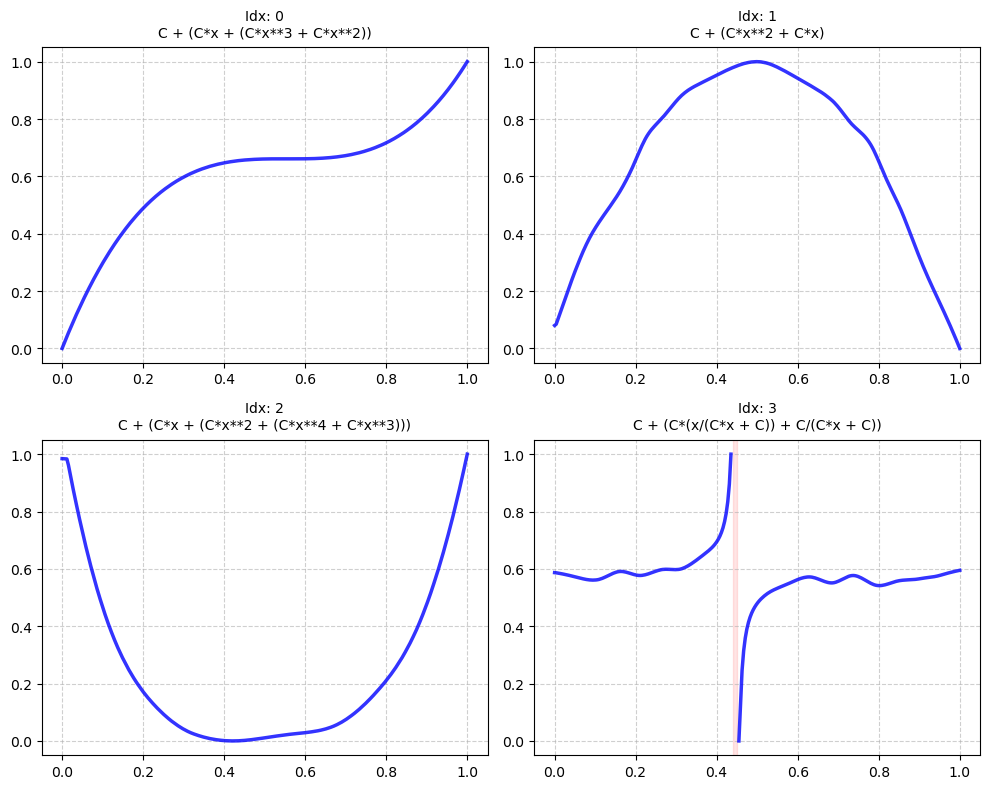

In [3]:
dataset = SymbolicDataset(data_dir="../data", drawn_augmentation=False)

print("Примеры из датасета без аугментаций:")
dataset.visualize_batch(batch_size=4, apply_transform=False)

print("Те же примеры, но с аугментациями:")
dataset.visualize_batch(batch_size=4, indices=np.arange(4), apply_transform=True)

### Шаг 4: Sanity Check - Переобучение на одном батче

Если модель не способна идеально выучить один-единственный батч, значит, в архитектуре, данных или цикле обучения есть фундаментальная проблема. Лосс должен стремительно упасть до нуля.

In [ ]:
print("Запускаем проверку на переобучение...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size_check = 4

train_loader, _, vocab_size, pad_idx = build_dataloaders("../data", batch_size_check)
points, tokens = next(iter(train_loader))
points, tokens = points.to(device), tokens.to(device)

sanity_model = Plot2EqModel(vocab_size=vocab_size, pad_idx=pad_idx).to(device)
optimizer = optim.AdamW(sanity_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

sanity_model.train()
pbar = tqdm(range(200), desc="Overfitting one batch")
for i in pbar:
    tgt_input = tokens[:, :-1]
    tgt_expected = tokens[:, 1:].contiguous().view(-1)
    
    optimizer.zero_grad()
    logits = sanity_model(points, tgt_input).view(-1, vocab_size)
    loss = criterion(logits, tgt_expected)
    loss.backward()
    optimizer.step()
    
    if i % 10 == 0:
        pbar.set_postfix({"loss": f"{loss.item():.6f}"})

print(f"\nФинальный лосс на батче: {loss.item():.6f}") # type: ignore

sanity_model.eval()
with torch.no_grad():
    logits = sanity_model(points, tokens[:, :-1])
    preds = logits.argmax(dim=-1)
    tgt_expected_seq = tokens[:, 1:]
    
    mask = (tgt_expected_seq != pad_idx)
    correct = ((preds == tgt_expected_seq) & mask).all(dim=1).sum().item()
    accuracy = correct / batch_size_check
    
print(f"Точность на батче: {accuracy:.2%}")
if accuracy == 1.0:
    print("Sanity check пройден! Модель способна к обучению.")
else:
    print("Sanity check не пройден. Проверьте архитектуру или пайплайн.")

Запускаем проверку на переобучение...
Loading base dataset...
Загружаем 57 файлов в память


100%|██████████| 57/57 [00:07<00:00,  7.26it/s]


### Шаг 5: Полноценное обучение

In [ ]:
wandb.login()

In [ ]:
train_config = TrainConfig(
    data_dir="../data",
    project_name="Plot2Eq",
    
    batch_size=256,
    epochs=1000,
    lr=3e-4, 
    warmup_ratio=0.05,
    # resume_from_checkpoint="checkpoints/best_model.pth"
)

print(f"Начинаем обучение с конфигом:\n{train_config}")

try:
    train_loop(train_config)
except KeyboardInterrupt:
    print("\nОбучение прервано. Завершаем сессию wandb...")
finally:
    if wandb.run is not None:
        wandb.finish()
        print("Сессия wandb завершена.")